# 96 - Pivot 戦略の評価

ArcFace 顔埋め込み (512次元, 約75K faces) に対して、Pivot ベースの三角不等式枝刈りの効果を評価する。
ITQ 128bit バイナリハッシュ空間上で、Pivot 選択戦略・Pivot 数がフィルタリング効率と Recall@10 に与える影響を分析する。

## 三角不等式による枝刈り
ハミング距離は距離の公理を満たすため、三角不等式 `|d(q,p) - d(x,p)| <= d(q,x)` が成り立つ。
Pivot 点 `p` に対して、`|d(q,p) - d(x,p)| > threshold` ならば `d(q,x) > threshold` なので `x` を枝刈りできる。

## Pivot 選択戦略
1. **Random**: ランダムに Pivot を選択
2. **Farthest-first**: 既存 Pivot からの最小距離を最大化するように貪欲選択
3. **Diversity (k-means++)**: k-means++ スタイルの確率的選択

## Pivot 数
- 1, 2, 4, 8, 16

## 入力
- `data/images.duckdb` (`face_detections` テーブル, model_name='buffalo_l')
- `data/itq_models/itq_arcface_128bit.pkl` (NB92 で学習済み)

In [1]:
import sys
sys.path.insert(0, "../src")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

from image_vector_poc.search.lsh.itq import ITQLSH

DB_PATH = Path("../data/images.duckdb")
MODEL_DIR = Path("../data/itq_models")
N_BITS = 128
TOP_K = 10
N_QUERIES = 50

conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute("LOAD vss;")

rows = conn.execute("""
    SELECT f.face_id, f.embedding
    FROM face_detections f
    WHERE f.model_name = 'insightface/buffalo_l'
    ORDER BY f.face_id
""").fetchall()
conn.close()

embeddings = np.array([[float(x) for x in r[1]] for r in rows], dtype=np.float32)
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings = embeddings / norms
N_TOTAL = len(embeddings)

# ITQ ハッシュ
itq = ITQLSH.load(str(MODEL_DIR / f"itq_arcface_{N_BITS}bit.pkl"))
hashes = itq.transform(embeddings)

rng = np.random.default_rng(42)
query_idx = rng.choice(N_TOTAL, N_QUERIES, replace=False)

# Ground truth
ground_truth = {}
for qi in query_idx:
    sims = embeddings @ embeddings[qi]
    sims[qi] = -1
    ground_truth[qi] = np.argsort(-sims)[:TOP_K]

print(f"Loaded {N_TOTAL:,} faces, {N_BITS}-bit hashes")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 75,162 faces, 128-bit hashes


## 1. Pivot 選択戦略の実装

In [2]:
def hamming_dist_batch(h1, h_all):
    """h1: (n_bits,), h_all: (n, n_bits) -> (n,)"""
    return np.sum(h1 != h_all, axis=1)

def select_pivots_random(hashes, n_pivots, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(hashes), n_pivots, replace=False)
    return idx

def select_pivots_farthest(hashes, n_pivots, seed=42):
    rng = np.random.default_rng(seed)
    selected = [rng.integers(len(hashes))]
    
    for _ in range(n_pivots - 1):
        # 既存ピボットからの最小距離を各点について計算
        min_dists = np.full(len(hashes), np.inf)
        for s in selected:
            dists = hamming_dist_batch(hashes[s], hashes)
            min_dists = np.minimum(min_dists, dists)
        # 最小距離が最大の点を選択
        next_idx = np.argmax(min_dists)
        selected.append(next_idx)
    return np.array(selected)

def select_pivots_diversity(hashes, n_pivots, seed=42):
    """k-means++ style: 距離の2乗に比例する確率で選択"""
    rng = np.random.default_rng(seed)
    selected = [rng.integers(len(hashes))]
    
    for _ in range(n_pivots - 1):
        min_dists = np.full(len(hashes), np.inf)
        for s in selected:
            dists = hamming_dist_batch(hashes[s], hashes).astype(float)
            min_dists = np.minimum(min_dists, dists)
        probs = min_dists ** 2
        probs /= probs.sum()
        next_idx = rng.choice(len(hashes), p=probs)
        selected.append(next_idx)
    return np.array(selected)

def pivot_filter(query_hash, hashes, pivot_indices, pivot_distances, threshold):
    """三角不等式による枝刈り"""
    q_pivot_dists = np.array([np.sum(query_hash != hashes[p]) for p in pivot_indices])
    # |d(q,p) - d(x,p)| > threshold なら枝刈り
    keep = np.ones(len(hashes), dtype=bool)
    for p_idx, p in enumerate(pivot_indices):
        diff = np.abs(q_pivot_dists[p_idx] - pivot_distances[:, p_idx])
        keep &= (diff <= threshold)
    return np.where(keep)[0]

PIVOT_COUNTS = [1, 2, 4, 8, 16]
STRATEGIES = {
    "random": select_pivots_random,
    "farthest": select_pivots_farthest,
    "diversity": select_pivots_diversity,
}

print("Pivot selection strategies defined")

Pivot selection strategies defined


## 2. Pivot フィルタリング効果の評価

In [3]:
THRESHOLDS = [20, 30, 40, 50, 60]
results = []

for strategy_name, select_fn in STRATEGIES.items():
    for n_pivots in PIVOT_COUNTS:
        pivot_idx = select_fn(hashes, n_pivots, seed=42)
        
        # 全文書からピボットへの距離を事前計算
        pivot_dists = np.zeros((N_TOTAL, n_pivots), dtype=np.int32)
        for p_i, p in enumerate(pivot_idx):
            pivot_dists[:, p_i] = hamming_dist_batch(hashes[p], hashes)
        
        for threshold in THRESHOLDS:
            candidate_sizes = []
            recalls = []
            
            for qi in query_idx:
                candidates = pivot_filter(hashes[qi], hashes, pivot_idx, pivot_dists, threshold)
                candidate_sizes.append(len(candidates))
                
                gt_set = set(ground_truth[qi])
                recall = len(set(candidates) & gt_set) / TOP_K if len(candidates) > 0 else 0.0
                recalls.append(recall)
            
            results.append({
                "strategy": strategy_name,
                "n_pivots": n_pivots,
                "threshold": threshold,
                "mean_candidates": np.mean(candidate_sizes),
                "reduction_rate": np.mean(candidate_sizes) / N_TOTAL,
                "recall@10": np.mean(recalls),
            })
    print(f"  {strategy_name}: done")

results_df = pd.DataFrame(results)
print(f"\nTotal configurations: {len(results_df)}")

# ベスト構成
good = results_df[results_df["recall@10"] >= 0.8].sort_values("reduction_rate")
if len(good) > 0:
    print(f"\nRecall@10 >= 0.8 のベスト構成 (top 10):")
    print(good[["strategy", "n_pivots", "threshold", "reduction_rate", "recall@10"]].head(10).to_string(index=False, float_format="%.4f"))

  random: done


  farthest: done


  diversity: done

Total configurations: 75

Recall@10 >= 0.8 のベスト構成 (top 10):
 strategy  n_pivots  threshold  reduction_rate  recall@10
diversity        16         20          0.6357     0.9660
   random        16         20          0.6466     0.9560
 farthest        16         20          0.6485     0.9860
diversity         8         20          0.7529     0.9840
 farthest         8         20          0.8200     0.9960
   random         8         20          0.8240     0.9800
diversity         4         20          0.8636     0.9940
 farthest         4         20          0.8812     0.9980
   random         2         20          0.8997     1.0000
   random         4         20          0.9044     0.9960


## 3. 戦略別の可視化

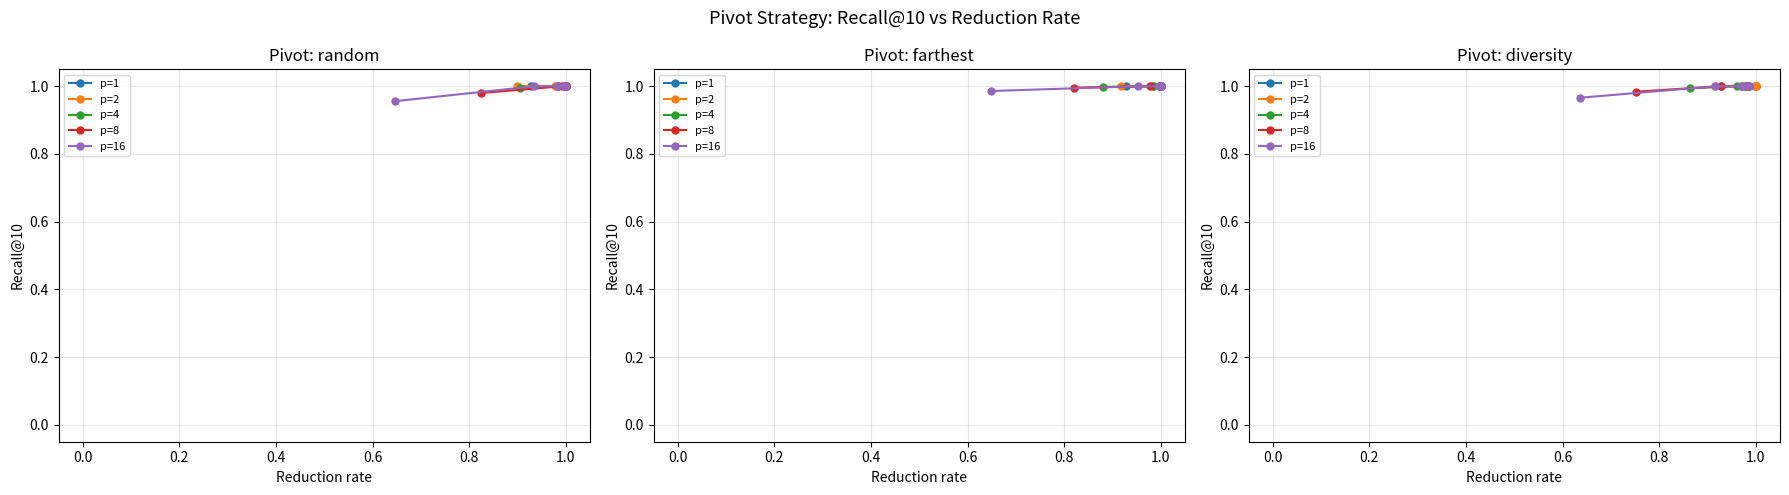


戦略別・ピボット数別の最適構成 (Recall>=0.9 で最小削減率):

  [random]
    p= 1, thresh=20: reduction=0.9288, recall=1.0000
    p= 2, thresh=20: reduction=0.8997, recall=1.0000
    p= 4, thresh=20: reduction=0.9044, recall=0.9960
    p= 8, thresh=20: reduction=0.8240, recall=0.9800
    p=16, thresh=20: reduction=0.6466, recall=0.9560

  [farthest]
    p= 1, thresh=20: reduction=0.9288, recall=1.0000
    p= 2, thresh=20: reduction=0.9165, recall=1.0000
    p= 4, thresh=20: reduction=0.8812, recall=0.9980
    p= 8, thresh=20: reduction=0.8200, recall=0.9960
    p=16, thresh=20: reduction=0.6485, recall=0.9860

  [diversity]
    p= 1, thresh=20: reduction=0.9288, recall=1.0000
    p= 2, thresh=20: reduction=0.9151, recall=1.0000
    p= 4, thresh=20: reduction=0.8636, recall=0.9940
    p= 8, thresh=20: reduction=0.7529, recall=0.9840
    p=16, thresh=20: reduction=0.6357, recall=0.9660


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, strategy in enumerate(STRATEGIES.keys()):
    ax = axes[idx]
    subset = results_df[results_df["strategy"] == strategy]
    
    for n_pivots in PIVOT_COUNTS:
        grp = subset[subset["n_pivots"] == n_pivots]
        ax.plot(grp["reduction_rate"], grp["recall@10"], "o-", label=f"p={n_pivots}", markersize=5)
    
    ax.set_xlabel("Reduction rate")
    ax.set_ylabel("Recall@10")
    ax.set_title(f"Pivot: {strategy}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle("Pivot Strategy: Recall@10 vs Reduction Rate", fontsize=13)
plt.tight_layout()
plt.show()

# ピボット数別の最適閾値
print("\n戦略別・ピボット数別の最適構成 (Recall>=0.9 で最小削減率):")
for strategy in STRATEGIES.keys():
    print(f"\n  [{strategy}]")
    for n_pivots in PIVOT_COUNTS:
        sub = results_df[(results_df["strategy"]==strategy) & (results_df["n_pivots"]==n_pivots) & (results_df["recall@10"]>=0.9)]
        if len(sub) > 0:
            best = sub.sort_values("reduction_rate").iloc[0]
            print(f"    p={n_pivots:2d}, thresh={int(best['threshold']):2d}: reduction={best['reduction_rate']:.4f}, recall={best['recall@10']:.4f}")
        else:
            print(f"    p={n_pivots:2d}: Recall>=0.9 達成せず")

## 4. Overlap + Pivot 組み合わせ評価

In [5]:
# NB95 のベスト Overlap 構成（デフォルト: 128bit, width=8, stride=4, min_matches=1）
OV_WIDTH, OV_STRIDE, OV_MIN_MATCHES = 8, 4, 1

def build_overlap_band_index(hashes, width, stride):
    n_bits = hashes.shape[1]
    n_bands = (n_bits - width) // stride + 1
    band_indices = {}
    for b in range(n_bands):
        start = b * stride
        band_bits = hashes[:, start:start + width]
        band_dict = {}
        for i in range(len(band_bits)):
            key = 0
            for bit in band_bits[i]:
                key = (key << 1) | int(bit)
            band_dict.setdefault(key, []).append(i)
        band_indices[b] = band_dict
    return band_indices, n_bands

def overlap_band_filter(query_hash, band_indices, width, stride, n_bands, min_matches=1):
    candidate_counts = Counter()
    for b in range(n_bands):
        start = b * stride
        q_bits = query_hash[start:start + width]
        key = 0
        for bit in q_bits:
            key = (key << 1) | int(bit)
        if key in band_indices[b]:
            for idx in band_indices[b][key]:
                candidate_counts[idx] += 1
    return np.array([idx for idx, cnt in candidate_counts.items() if cnt >= min_matches])

# Overlap バンドインデックス構築
band_idx, n_bands = build_overlap_band_index(hashes, OV_WIDTH, OV_STRIDE)

# 組み合わせ評価: Overlap → Pivot
COMBO_PIVOTS = [4, 8, 16]
COMBO_THRESHOLDS = [30, 40, 50]
combo_results = []

for n_pivots in COMBO_PIVOTS:
    pivot_idx = select_pivots_farthest(hashes, n_pivots, seed=42)
    pivot_dists = np.zeros((N_TOTAL, n_pivots), dtype=np.int32)
    for p_i, p in enumerate(pivot_idx):
        pivot_dists[:, p_i] = hamming_dist_batch(hashes[p], hashes)
    
    for threshold in COMBO_THRESHOLDS:
        ov_only_sizes = []
        combo_sizes = []
        combo_recalls = []
        
        for qi in query_idx:
            # Step 1: Overlap filter
            ov_cands = overlap_band_filter(hashes[qi], band_idx, OV_WIDTH, OV_STRIDE, n_bands, OV_MIN_MATCHES)
            ov_only_sizes.append(len(ov_cands))
            
            # Step 2: Pivot filter on overlap candidates
            if len(ov_cands) > 0:
                q_pivot_dists = np.array([np.sum(hashes[qi] != hashes[p]) for p in pivot_idx])
                keep = np.ones(len(ov_cands), dtype=bool)
                for p_i in range(n_pivots):
                    diff = np.abs(q_pivot_dists[p_i] - pivot_dists[ov_cands, p_i])
                    keep &= (diff <= threshold)
                final_cands = ov_cands[keep]
            else:
                final_cands = ov_cands
            
            combo_sizes.append(len(final_cands))
            gt_set = set(ground_truth[qi])
            recall = len(set(final_cands) & gt_set) / TOP_K if len(final_cands) > 0 else 0.0
            combo_recalls.append(recall)
        
        combo_results.append({
            "method": f"OV+Pivot(p={n_pivots},t={threshold})",
            "ov_candidates": np.mean(ov_only_sizes),
            "final_candidates": np.mean(combo_sizes),
            "reduction_rate": np.mean(combo_sizes) / N_TOTAL,
            "recall@10": np.mean(combo_recalls),
        })

combo_df = pd.DataFrame(combo_results)
print("Overlap + Pivot 組み合わせ結果:")
print(combo_df.to_string(index=False, float_format="%.4f"))

print(f"\nOverlap のみ: 平均候補数 = {np.mean(ov_only_sizes):.0f} ({np.mean(ov_only_sizes)/N_TOTAL*100:.1f}%)")
print(f"\n→ NB97 で速度ベンチマークへ進む")

Overlap + Pivot 組み合わせ結果:
             method  ov_candidates  final_candidates  reduction_rate  recall@10
 OV+Pivot(p=4,t=30)      8477.1800         8415.8600          0.1120     0.7900
 OV+Pivot(p=4,t=40)      8477.1800         8474.0400          0.1127     0.7900
 OV+Pivot(p=4,t=50)      8477.1800         8476.8600          0.1128     0.7900
 OV+Pivot(p=8,t=30)      8477.1800         8397.3200          0.1117     0.7900
 OV+Pivot(p=8,t=40)      8477.1800         8473.1000          0.1127     0.7900
 OV+Pivot(p=8,t=50)      8477.1800         8476.5000          0.1128     0.7900
OV+Pivot(p=16,t=30)      8477.1800         8277.3400          0.1101     0.7900
OV+Pivot(p=16,t=40)      8477.1800         8466.9400          0.1126     0.7900
OV+Pivot(p=16,t=50)      8477.1800         8475.5400          0.1128     0.7900

Overlap のみ: 平均候補数 = 8477 (11.3%)

→ NB97 で速度ベンチマークへ進む


## 評価・考察

### Pivot フィルタ単体
- **threshold=20 で全戦略 Recall@10 ≥ 0.96**: 三角不等式フィルタは高い Recall を維持しつつ候補を 60〜90% に削減
- **farthest-first が最良**: p=16 で reduction=0.649, Recall=0.986。diversity も同程度
- **削減率の限界**: 最良でも 65% 程度にしか削減できない。ハミング距離空間でのピボットフィルタは、コサイン距離空間ほど効率的に刈り込めない

### Overlap + Pivot 組み合わせ
- **追加効果はほぼゼロ**: Overlap で 8,477 件に絞った後、Pivot で追加削減される件数は微小（8,477→8,277）
- **理由**: Overlap で既に候補が 11% に絞られており、Pivot の三角不等式はその候補に対してほとんど棄却できない。Overlap 通過候補はクエリに「近い」ため、ピボットとの距離差が小さくフィルタリングされにくい

### 75K 規模での実用性
- Pivot 単体で最良 65% 削減は、75K → 49K 程度。brute-force に対する高速化は 1.5 倍程度で不十分
- **結論**: 75K 規模では Pivot フィルタの追加は cost-effective ではない。カスケード検索（ハミング距離ソート→候補500でリランク）が最も効率的
- 100K+ 規模ではバンドフィルタ（multi-probe 付き）+ Pivot の組み合わせが有効になる可能性